In [23]:
%load_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'imp'

In [1]:
!pip install medmnist

In [14]:
!git clone https://github.com/Felix982/XAI-project.git
%cd XAI-project

import os, sys
sys.path.append(os.getcwd())

fatal: destination path 'XAI-project' already exists and is not an empty directory.
/content/XAI-project/XAI-project


In [26]:
!git pull origin main
%cd XAI-project

remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 7 (delta 2), reused 7 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (7/7), 86.11 KiB | 3.91 MiB/s, done.
From https://github.com/Felix982/XAI-project
 * branch            main       -> FETCH_HEAD
   a151ee0..9164fcd  main       -> origin/main
Updating a151ee0..9164fcd
Fast-forward
 notebooks/01_train_classifier.ipynb            | 484 ++++++++++++++++++++
 notebooks/02_pretrained_diffusion_sanity.ipynb | 591 +++++++++++++++++++++++++
 training/train_classifier.py                   |   6 +-
 3 files changed, 1080 insertions(+), 1 deletion(-)
/content/XAI-project/XAI-project


In [28]:
import os
import sys
import torch

%cd /content/XAI-project
sys.path.append(os.getcwd())

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")

/content/XAI-project
True
Tesla T4


In [32]:
import importlib
import training.train_classifier
importlib.reload(training.train_classifier)
from training.train_classifier import TrainConfig, train_classifier

cfg = TrainConfig(
    data_root="./data",
    image_size=32,
    batch_size=128,
    num_channels=3,
    num_workers=2,
    lr=1e-3,
    max_epochs=30,
    early_stopping_patience=5,
    output_dir="./outputs/classifier",
)

results = train_classifier(cfg)
results

TypeError: get_image_transform() got an unexpected keyword argument 'num_channels'

In [5]:
from models.classifier import SmallCNNClassifier

device = "cuda" if torch.cuda.is_available() else "cpu"

model = SmallCNNClassifier(
    in_channels=1,
    base_channels=32,
    dropout=0.1,
).to(device)

ckpt = torch.load("./outputs/classifier/classifier_best.pt", map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

SmallCNNClassifier(
  (features): Sequential(
    (0): ConvBlock(
      (block): Sequential(
        (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
        (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
        (7): Dropout(p=0.1, inplace=False)
      )
    )
    (1): ConvBlock(
      (block): Sequential(
        (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(

In [37]:
import matplotlib.pyplot as plt
importlib.reload(data.medmnist)
importlib.reload(data.transforms)


test_loader = data.medmnist.get_dataloader(
    split="test",
    batch_size=16,
    image_size=32,
    root="./data",
    shuffle=False,
    num_workers=2,
)

batch = next(iter(test_loader))
images = batch["image"].to(device)
labels = batch["label"].to(device)

with torch.no_grad():
    logits = model(images)
    probs = torch.sigmoid(logits)
    preds = (probs >= 0.5).long()

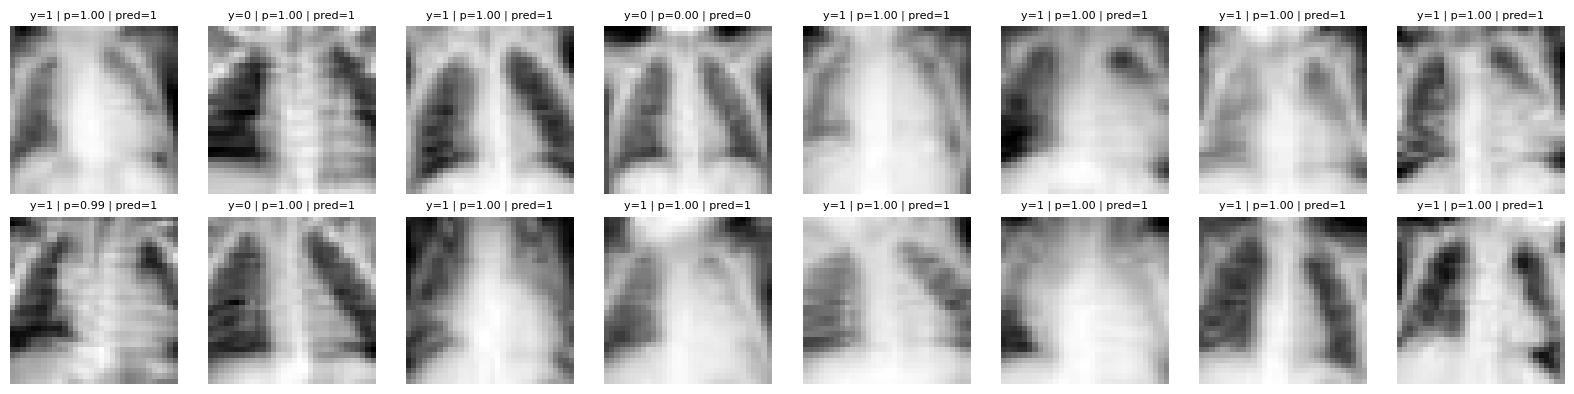

In [38]:
def denormalize(x):
    return (x * 0.5) + 0.5

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
axes = axes.flatten()

for i in range(16):
    img = denormalize(images[i].cpu()).squeeze().numpy()
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(
        f"y={labels[i].item()} | p={probs[i].item():.2f} | pred={preds[i].item()}",
        fontsize=8
    )
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [39]:
from google.colab import files
files.download("./outputs/classifier/classifier_best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>